# US-03 — Transformer para Classificação de Falhas em Rolamentos

**Objetivo:** Treinar um Transformer encoder (PyTorch puro) para classificar as 4 classes de falha no rolamento B1 do compressor EGB-250.

**Comparação justa com GAT:** este notebook executa **20 treinos independentes** com o mesmo conjunto fixo de seeds usado no GAT (`42..61`).

**Arquitetura atual (fase: mínima):**
```
Input (B, 4, 4096)
  → Input Projection: Linear(4 → 64) por time-step
  → Positional Encoding (sinusoidal)
  → 2 × TransformerEncoderLayer (d_model=64, nhead=4, dim_ff=128, dropout=0.0)
  → Global Average Pooling
  → Linear(64 → 4)
```

**Tabela de fases (aumentar se underfitting/baixa acurácia):**

| Parâmetro | Mínima (atual) | Ideal | Máxima |
|-----------|---------------|-------|--------|
| `D_MODEL` | 64 | 128 | 256 |
| `NHEAD` | 4 | 8 | 8 |
| `NUM_LAYERS` | 2 | 4 | 6 |
| `DIM_FF` | 128 | 256 | 512 |
| `DROPOUT` | 0.0 | 0.1 | 0.2 |
| `BATCH_SIZE` | 64 | 128 | 256 |
| `LR` | 1e-3 | 1e-4 | 1e-4 |
| `PATIENCE` | 5 | 10 | 15 |
| `SCHED_PATIENCE` | 3 | 5 | 7 |

**Inputs:** `data/processed/X_*.npy`, `y_*.npy` — **já normalizados** (StandardScaler aplicado em US-02). Não reaplicar scaler.

**Output principal:** pasta `models/transformer_runs_20` com 20 checkpoints (`transformer_run_01.pt` ... `transformer_run_20.pt`).


## 1. Setup e Seeds

In [ ]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -- Environment detection (local vs Google Colab) --------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_models_comparison")
    if not COLAB_REPO.exists():
        os.system(
            "git clone https://github.com/camara0729/anomaly_detection_models_comparison.git "
            "/content/anomaly_detection_models_comparison"
        )
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = Path.cwd().resolve().parent if (Path.cwd().name == "notebooks") else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.transformer import (
    VibrationTransformer,
    EarlyStopping,
    make_dataloaders,
    epoch_step,
)

# -- Seeds -------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -- Device ------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")

Device: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM: 4.3 GB
Project root: /home/camara/workspace/projetos_educacionais/anomaly_detection_comparison


## 2. Carregar Dados

In [2]:
# ── Dados no Colab: copiar de Google Drive ────────────────────────────────
# Execute esta célula apenas no Colab.
# Faça upload dos arquivos de data/processed/ para o seu Google Drive e
# ajuste DRIVE_DATA_DIR abaixo para o caminho correto.
#
# Arquivos necessários (gerados pelo notebook 02_preprocessing):
#   X_train.npy, y_train.npy
#   X_val.npy,   y_val.npy
#   X_test.npy,  y_test.npy

if IN_COLAB:
    import shutil
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)

    # ← Ajuste este caminho para onde você salvou os .npy no Drive
    DRIVE_DATA_DIR = Path("/content/drive/MyDrive/anomaly_detection_comparison/data/processed")

    LOCAL_DATA_DIR = PROJECT_ROOT / "data" / "processed"
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

    files_needed = [
        "X_train.npy", "y_train.npy",
        "X_val.npy",   "y_val.npy",
        "X_test.npy",  "y_test.npy",
    ]
    for fname in files_needed:
        src = DRIVE_DATA_DIR / fname
        dst = LOCAL_DATA_DIR / fname
        if not dst.exists():
            shutil.copy(src, dst)
            print(f"Copied: {fname}")
        else:
            print(f"Already exists: {fname}")
    print("Done.")

In [3]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"

X_train = np.load(DATA_DIR / "X_train.npy")  # (n_train, 4, 4096) — já normalizado
y_train = np.load(DATA_DIR / "y_train.npy")  # (n_train,) int64
X_val   = np.load(DATA_DIR / "X_val.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print("Shapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")

# Verify data is pre-normalised (mean ≈ 0, std ≈ 1)
print(f"\nX_train global mean={X_train.mean():.4f}, std={X_train.std():.4f}  (expect ≈0, ≈1)")

CLASS_NAMES = ["Normal (P1)", "Inner Race (P2)", "Roller Element (P3)", "Outer Race (P4)"]

Shapes:
  X_train: (9720, 4, 4096)  y_train: (9720,)
  X_val:   (1944, 4, 4096)  y_val:   (1944,)
  X_test:  (2916, 4, 4096)  y_test:  (2916,)

X_train global mean=0.0000, std=1.0000  (expect ≈0, ≈1)


## 3. Hiperparâmetros

In [ ]:
# -- Architecture ------------------------------------------------------------------
N_CHANNELS   = X_train.shape[1]
WINDOW_SIZE  = X_train.shape[2]
N_CLASSES    = 4
D_MODEL      = 64
NHEAD        = 4
NUM_LAYERS   = 2
DIM_FF       = 128
DROPOUT      = 0.0

# -- Training ----------------------------------------------------------------------
BATCH_SIZE     = 64
LR             = 1e-3
MAX_EPOCHS     = 200
PATIENCE       = 5
SCHED_PATIENCE = 3

# -- Multi-run setup (padronizado com GAT) -----------------------------------------
NUM_RUNS = 20
RUN_SEEDS = list(range(42, 42 + NUM_RUNS))  # 42..61
assert len(RUN_SEEDS) == NUM_RUNS

from datetime import datetime

def make_unique_runset_dir(root_dir: Path, prefix: str = "runset") -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = root_dir / f"{prefix}_{timestamp}"
    suffix = 1
    while candidate.exists():
        candidate = root_dir / f"{prefix}_{timestamp}_{suffix:02d}"
        suffix += 1
    candidate.mkdir(parents=True, exist_ok=False)
    return candidate

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
RUNS_ROOT_DIR = MODELS_DIR / "transformer_runs_20"
RUNS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS_MODELS_DIR = make_unique_runset_dir(RUNS_ROOT_DIR)
RUN_RESULTS_PATH = RUNS_MODELS_DIR / "transformer_runs_summary.csv"

print(f"Architecture: d_model={D_MODEL}, nhead={NHEAD}, layers={NUM_LAYERS}, dim_ff={DIM_FF}, dropout={DROPOUT}")
print(
    f"Training: batch={BATCH_SIZE}, lr={LR}, max_epochs={MAX_EPOCHS}, "
    f"patience={PATIENCE}, sched_patience={SCHED_PATIENCE}"
)
print(f"Runs: {NUM_RUNS} with fixed seeds {RUN_SEEDS[0]}..{RUN_SEEDS[-1]}")
print(f"Runs root dir: {RUNS_ROOT_DIR}")
print(f"Active runset dir: {RUNS_MODELS_DIR}")

Architecture: d_model=64, nhead=4, layers=2, dim_ff=128, dropout=0.0
Training:     batch=64, lr=0.001, max_epochs=200, patience=5, sched_patience=3


## 4. DataLoaders

In [ ]:
train_loader_probe, val_loader_probe = make_dataloaders(
    X_train, y_train,
    X_val,   y_val,
    batch_size=BATCH_SIZE,
    seed=RUN_SEEDS[0],
)

print(f"Train batches: {len(train_loader_probe)}  ({len(train_loader_probe.dataset)} samples)")
print(f"Val batches:   {len(val_loader_probe)}  ({len(val_loader_probe.dataset)} samples)")

for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(y, minlength=N_CLASSES)
    print(f"  {split_name}: {dict(zip(range(N_CLASSES), counts))}")

Train batches: 152  (9720 samples)
Val batches:   31  (1944 samples)
  train: {0: 2430, 1: 2430, 2: 2430, 3: 2430}
  val: {0: 486, 1: 486, 2: 486, 3: 486}
  test: {0: 729, 1: 729, 2: 729, 3: 729}


## 5. Modelo

In [ ]:
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_transformer_model(seed: int) -> VibrationTransformer:
    set_all_seeds(seed)
    return VibrationTransformer(
        n_channels=N_CHANNELS,
        window_size=WINDOW_SIZE,
        n_classes=N_CLASSES,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FF,
        dropout=DROPOUT,
    )

probe_model = build_transformer_model(RUN_SEEDS[0]).to(DEVICE)
n_params = sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(probe_model)

Trainable parameters: 67,524
VibrationTransformer(
  (input_proj): Linear(in_features=4, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)


## 6. Optimizer, Scheduler, EarlyStopping

In [ ]:
def train_single_run(run_idx: int, run_seed: int):
    train_loader, val_loader = make_dataloaders(
        X_train, y_train,
        X_val,   y_val,
        batch_size=BATCH_SIZE,
        seed=run_seed,
    )

    model = build_transformer_model(run_seed).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=SCHED_PATIENCE
    )
    early_stop = EarlyStopping(patience=PATIENCE)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
    }

    checkpoint_path = RUNS_MODELS_DIR / f"transformer_run_{run_idx:02d}.pt"
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0

    t_start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = epoch_step(
            model, train_loader, loss_fn, optimizer=optimizer, train=True, device=DEVICE
        )
        vl_loss, vl_acc = epoch_step(
            model, val_loader, loss_fn, optimizer=None, train=False, device=DEVICE
        )

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        scheduler.step(vl_loss)
        early_stop.step(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_val_acc = vl_acc
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint_path)

        if early_stop.should_stop:
            break

    train_seconds = time.time() - t_start
    return {
        "run": run_idx,
        "seed": run_seed,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "train_seconds": train_seconds,
        "model_path": str(checkpoint_path),
    }, history

Optimizer: Adam lr=0.001
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
EarlyStopping: patience=5


## 7. Treinar Transformer 20 Vezes (Seeds Fixas)

In [ ]:
all_run_histories = {}
run_results = []

for run_idx, run_seed in enumerate(RUN_SEEDS, start=1):
    print(f"[Run {run_idx:02d}/{NUM_RUNS}] seed={run_seed}")
    result, run_history = train_single_run(run_idx=run_idx, run_seed=run_seed)
    run_results.append(result)
    all_run_histories[run_idx] = run_history
    print(
        f"  best_epoch={result['best_epoch']}, "
        f"best_val_loss={result['best_val_loss']:.4f}, "
        f"best_val_acc={result['best_val_acc'] * 100:.2f}%, "
        f"time={result['train_seconds']:.1f}s"
    )

results_df = pd.DataFrame(run_results).sort_values("run").reset_index(drop=True)
results_df.to_csv(RUN_RESULTS_PATH, index=False)

best_row = results_df.sort_values("best_val_loss", ascending=True).iloc[0]
BEST_RUN = int(best_row["run"])
BEST_SEED = int(best_row["seed"])
CHECKPOINT_PATH = Path(best_row["model_path"])
history = all_run_histories[BEST_RUN]

print("\nResumo das 20 execucoes:")
print(results_df[["run", "seed", "best_epoch", "best_val_loss", "best_val_acc", "train_seconds"]].to_string(index=False))
print(f"\nMelhor run: {BEST_RUN:02d} (seed={BEST_SEED})")
print(f"Melhor val_loss: {best_row['best_val_loss']:.4f}")
print(f"Checkpoint selecionado para avaliacao: {CHECKPOINT_PATH}")
print(f"Resumo salvo em: {RUN_RESULTS_PATH}")

model = build_transformer_model(BEST_SEED).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
loss_fn = nn.CrossEntropyLoss()

Epoch   1/200 | tr_loss=0.3787 tr_acc=0.8404 | vl_loss=0.3042 vl_acc=0.8945 | lr=1.00e-03 | 594s
Epoch  10/200 | tr_loss=0.0130 tr_acc=0.9954 | vl_loss=0.2164 vl_acc=0.9357 | lr=1.00e-03 | 5935s

Early stopping at epoch 16. Best val_loss=0.0781

Total training time: 9500.1s
Best val_loss: 0.0781
Model saved to: /home/camara/workspace/projetos_educacionais/anomaly_detection_comparison/models/transformer_best.pt


In [ ]:
run_model_files = sorted(RUNS_MODELS_DIR.glob("transformer_run_*.pt"))
print(f"Total de checkpoints encontrados: {len(run_model_files)}")
assert len(run_model_files) == NUM_RUNS, (
    f"Esperados {NUM_RUNS} modelos, encontrados {len(run_model_files)}"
)

print("\nModelos salvos:")
for model_file in run_model_files:
    print(f"  - {model_file.name}")

print(f"\nPasta final dos 20 modelos: {RUNS_MODELS_DIR}")
print(f"Resumo dos runs: {RUN_RESULTS_PATH}")

## 8. Curvas de Treinamento (Melhor Run)

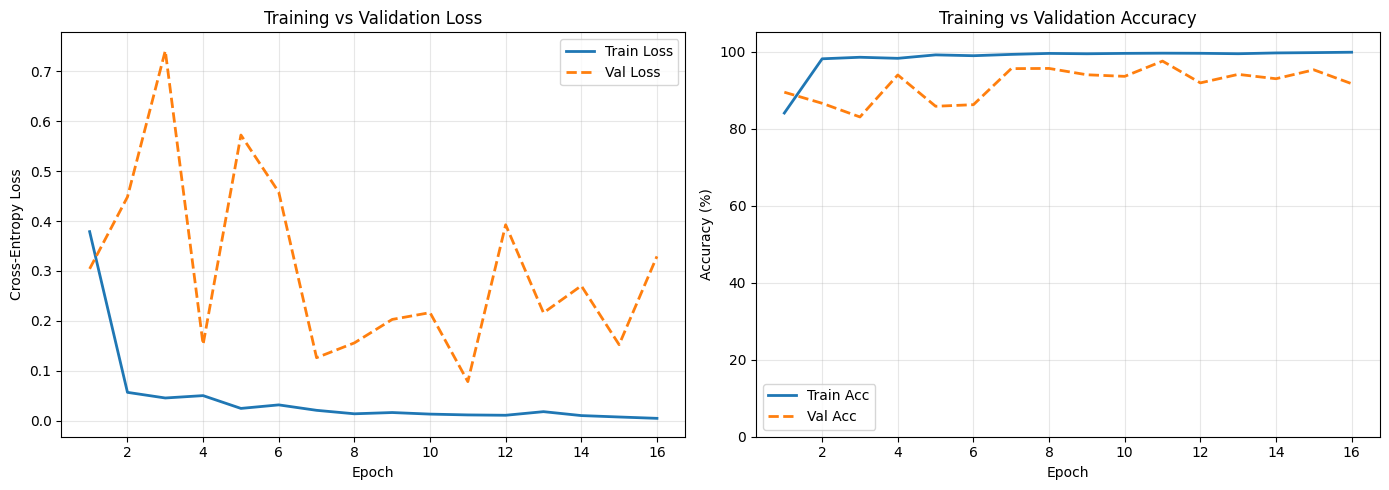

Saved: docs/figures/03_transformer_training_curves.png


In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title(f"Training vs Validation Loss — Transformer (Run {BEST_RUN:02d})")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", linewidth=2)
ax2.plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title(f"Training vs Validation Accuracy — Transformer (Run {BEST_RUN:02d})")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
curves_path = FIGURES_DIR / f"03_transformer_training_curves_run_{BEST_RUN:02d}.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

## 9. Avaliação no Conjunto de Teste (Melhor Run)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

print(f"Avaliando melhor run: {BEST_RUN:02d} (checkpoint: {CHECKPOINT_PATH.name})")

model.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
model.eval()

test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

test_loss, test_acc = epoch_step(
    model, test_loader, loss_fn, optimizer=None, train=False, device=DEVICE
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss:     0.0678
Test Accuracy: 97.87%


## 10. Matriz de Confusão (Teste, Melhor Run)

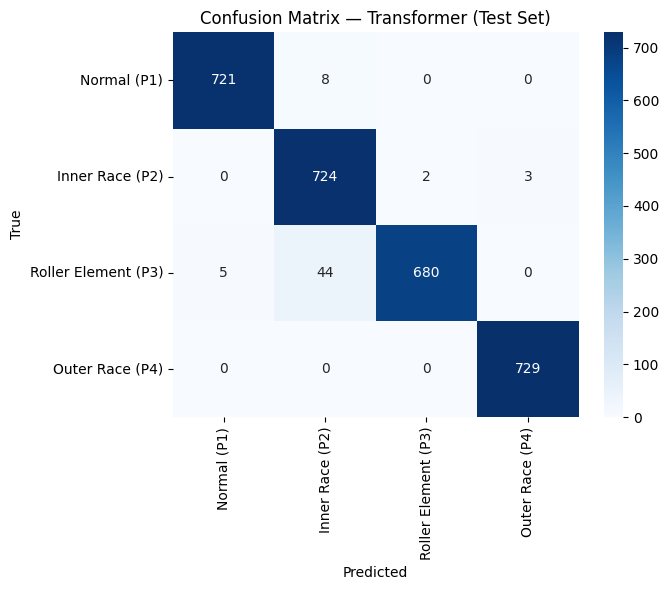


Classification Report:
                     precision    recall  f1-score   support

        Normal (P1)       0.99      0.99      0.99       729
    Inner Race (P2)       0.93      0.99      0.96       729
Roller Element (P3)       1.00      0.93      0.96       729
    Outer Race (P4)       1.00      1.00      1.00       729

           accuracy                           0.98      2916
          macro avg       0.98      0.98      0.98      2916
       weighted avg       0.98      0.98      0.98      2916



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(DEVICE)
        logits = model(x_b)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_b.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — Transformer (Test Set, Run {BEST_RUN:02d})")
plt.tight_layout()
cm_path = FIGURES_DIR / f"03_transformer_confusion_matrix_run_{BEST_RUN:02d}.png"
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClassification Report (Run {BEST_RUN:02d}):")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print(f"Saved: {cm_path}")

## 11. Resumo

Este notebook foi padronizado para comparação com o GAT usando o mesmo conjunto de seeds fixas (`42..61`) em 20 execuções sem sobrescrever runs anteriores.

**Saídas geradas:**
- `models/transformer_runs_20/runset_YYYYMMDD_HHMMSS/transformer_run_01.pt` ... `transformer_run_20.pt`
- `models/transformer_runs_20/runset_YYYYMMDD_HHMMSS/transformer_runs_summary.csv`
- `docs/figures/03_transformer_training_curves_run_XX.png` (melhor run)
- `docs/figures/03_transformer_confusion_matrix_run_XX.png` (melhor run)

**Validação no notebook:**
- Execução de 20 runs com seeds fixas e pareadas
- Assertiva de exatamente 20 checkpoints
- Avaliação de teste usando automaticamente o melhor run por `val_loss`